Cell 1 | Setup

In [1]:
# %load_ext autoreload

# %autoreload 2
%reload_ext autoreload

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load processed corpora and decode metadata
def load_with_metadata(path):
    df = pd.read_parquet(path)
    df["metadata"] = df["metadata"].apply(json.loads)
    return df

edgar = load_with_metadata(PROCESSED_DIR / "edgar_processed_n100.parquet")
earnings = load_with_metadata(PROCESSED_DIR / "earnings_processed_n100.parquet")
combined = load_with_metadata(PROCESSED_DIR / "combined_corpus_n200.parquet")

# Set consistent style for thesis figures
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300  # high-res for thesis
plt.rcParams["savefig.bbox"] = "tight"

print(f"EDGAR: {len(edgar)} units, Earnings: {len(earnings)} units, Combined: {len(combined)}")

EDGAR: 319 units, Earnings: 160 units, Combined: 479


### Cell 2 | Figure 1: Document unit counts by source and subtype

Why this figure works for thesis: it shows the structural difference between the two corpora at a glance. 
EDGAR is bounded by sections (89 / 84 / 88 / 59); earnings is split by spoken structure (74 prepared + 74 QA + 26 full). 
One image, two stories, immediate visual contrast.

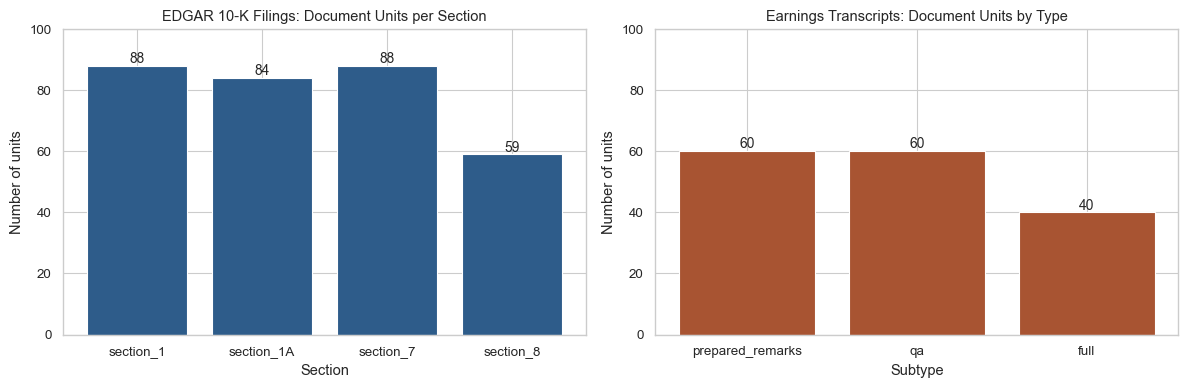

Saved: d:\General IT\AI-ML-LJMU\final_thesis\code\reports\figures\fig01_document_units_by_corpus.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: EDGAR by section
edgar_counts = edgar["subtype"].value_counts().reindex(
    ["section_1", "section_1A", "section_7", "section_8"]
)
axes[0].bar(edgar_counts.index, edgar_counts.values, color="#2E5C8A")
axes[0].set_title("EDGAR 10-K Filings: Document Units per Section")
axes[0].set_xlabel("Section")
axes[0].set_ylabel("Number of units")
axes[0].set_ylim(0, 100)
for i, v in enumerate(edgar_counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=10)

# Right: Earnings by subtype
earn_counts = earnings["subtype"].value_counts().reindex(
    ["prepared_remarks", "qa", "full"]
)
axes[1].bar(earn_counts.index, earn_counts.values, color="#A85432")
axes[1].set_title("Earnings Transcripts: Document Units by Type")
axes[1].set_xlabel("Subtype")
axes[1].set_ylabel("Number of units")
axes[1].set_ylim(0, 100)
for i, v in enumerate(earn_counts.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig01_document_units_by_corpus.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig01_document_units_by_corpus.png'}")

<h4>Figure 1 - Document Unit Counts by Source and Subtype.</h4>
<hr>

- The left panel shows the four indexed EDGAR 10-K sections: sections 1 (Business), 1A (Risk Factors), and 7 (MD&A) each contribute 84–88 units out of 100 filings, while section 8 (Financial Statements) yields only 59 substantive units because 41 filings contain cross-references rather than inline content. 
- The right panel shows the earnings transcript processing output: 60 prepared-remarks and 60 Q&A units from genuine splits, plus 40 full-call units from transcripts where no reliable Q&A boundary was detected. 
- The 1:1 ratio between prepared remarks and Q&A confirms that each successfully split call produces exactly one unit of each subtype. 
- Total corpus: 319 EDGAR units + 160 earnings units = 479 document units.

### Cell 3 | Figure 2: Length distribution comparison
Why this figure works: it visualizes the "formal vs conversational" hypothesis directly. 
EDGAR sections span 1K to 400K chars (huge variance, especially section_1A and section_8). 
Earnings units are tighter, 5K-85K. The log scale handles the outliers honestly without distorting the story.

C:\Users\anshu\AppData\Local\Temp\ipykernel_23216\3439113011.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


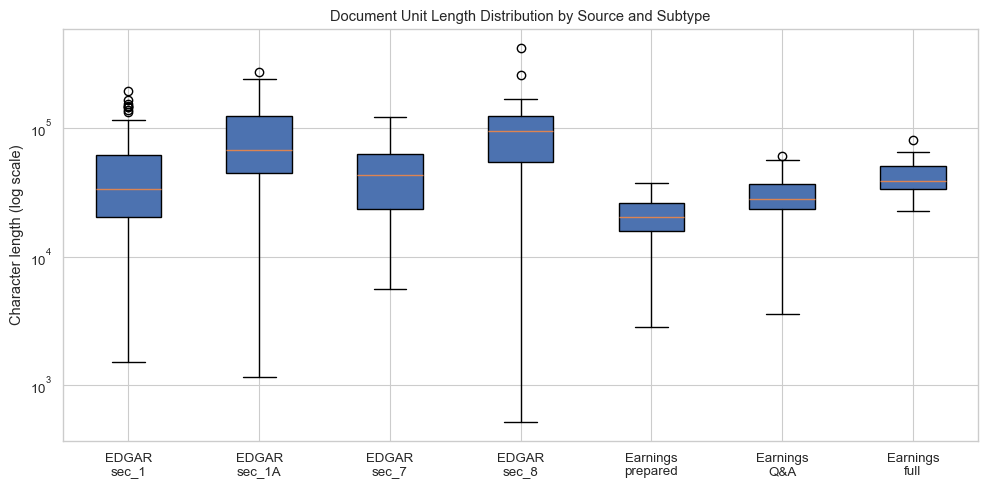

Saved: d:\General IT\AI-ML-LJMU\final_thesis\code\reports\figures\fig02_length_distribution.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

# Use log scale because EDGAR has 420K outlier
ax.boxplot(
    [
        edgar[edgar["subtype"] == "section_1"]["char_length"],
        edgar[edgar["subtype"] == "section_1A"]["char_length"],
        edgar[edgar["subtype"] == "section_7"]["char_length"],
        edgar[edgar["subtype"] == "section_8"]["char_length"],
        earnings[earnings["subtype"] == "prepared_remarks"]["char_length"],
        earnings[earnings["subtype"] == "qa"]["char_length"],
        earnings[earnings["subtype"] == "full"]["char_length"],
    ],
    labels=[
        "EDGAR\nsec_1", "EDGAR\nsec_1A", "EDGAR\nsec_7", "EDGAR\nsec_8",
        "Earnings\nprepared", "Earnings\nQ&A", "Earnings\nfull"
    ],
    patch_artist=True,
)
ax.set_yscale("log")
ax.set_ylabel("Character length (log scale)")
ax.set_title("Document Unit Length Distribution by Source and Subtype")

# Color boxes by corpus
colors = ["#2E5C8A"]*4 + ["#A85432"]*3
for patch, color in zip(ax.artists if hasattr(ax, 'artists') else ax.patches, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig02_length_distribution.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig02_length_distribution.png'}")

<h4>Figure 2 - Document Unit Length Distribution (Log Scale).</h4>
<hr>

- Boxplots reveal a substantial length asymmetry between corpora. 
- EDGAR sections span roughly 10³ to 10⁵ characters, with section_1A (Risk Factors) and section_8 (Financial Statements) exhibiting the widest spread and highest medians — both around 70K–95K characters. 
- Earnings units are more compact and tightly distributed: prepared remarks cluster around 20K characters, Q&A around 30K, and full calls around 40K. 
- The log scale accommodates outliers exceeding 400K characters in EDGAR section_8, confirmed as legitimate large filers. 
- This length asymmetry directly informs the Phase 3 chunking strategy, where EDGAR sections will produce substantially more chunks per document unit than earnings transcripts.

### Cell 4 | Figure 3: Sector distribution in earnings sample

Why this figure works: it shows the sample isn't accidentally skewed to one sector. The proposal explicitly mentions GICS stratification — this figure either confirms balanced coverage or shows where you'd need to stratify in the scale-up.

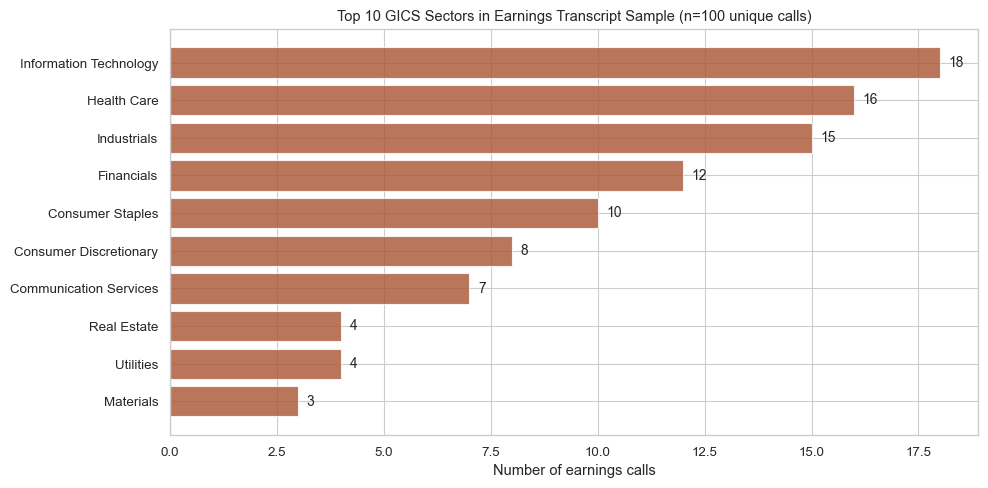

Saved: d:\General IT\AI-ML-LJMU\final_thesis\code\reports\figures\fig03_earnings_sector_distribution.png


In [4]:
# Extract sector per unique call (not per doc unit, since one call = up to 2 units)
sectors_per_call = (
    earnings["metadata"]
    .apply(lambda m: (m["call_idx"], m.get("sector", "Unknown")))
    .drop_duplicates()
    .apply(lambda pair: pair[1])
)

sector_counts = sectors_per_call.value_counts().head(10)
n_unique_calls = sectors_per_call.shape[0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sector_counts.index[::-1], sector_counts.values[::-1], color="#A85432", alpha=0.8)
ax.set_xlabel("Number of earnings calls")
ax.set_title(f"Top 10 GICS Sectors in Earnings Transcript Sample (n={n_unique_calls} unique calls)")
for i, v in enumerate(sector_counts.values[::-1]):
    ax.text(v + 0.2, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig03_earnings_sector_distribution.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig03_earnings_sector_distribution.png'}")

<h4>Figure 3 - GICS Sector Distribution in Earnings Sample (n=100).</h4>
<hr>

- Random sampling at n=100 produces a technology-and-healthcare-heavy sample, with Information Technology (18), Health Care (16), and Industrials (15) together comprising nearly half the calls. 
- Materials (3), Utilities (4), and Real Estate (4) are under-represented. 
- This distribution reflects S&P 500 market-cap weighting rather than equal sector coverage. 
- For the planned n=500 scale-up, GICS-stratified sampling will be applied to ensure balanced sector representation, as sector-specific reporting language (e.g., non-GAAP reconciliations in Financials versus pipeline disclosures in Healthcare) may interact differently with retrieval mechanisms.

### Cell 5 | Figure 4: Transcript opening format breakdown

Why this figure works: it documents the participant-header finding visually. When written about the cleaning decision in methodology chapter, this figure is the evidence.

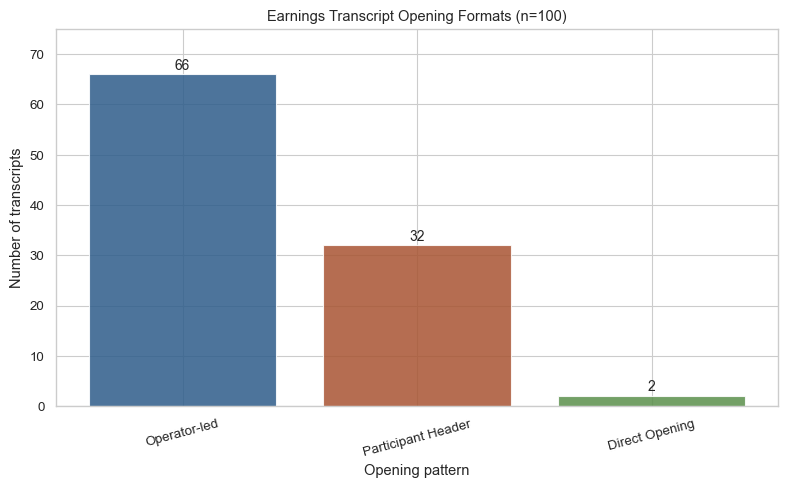

Saved: d:\General IT\AI-ML-LJMU\final_thesis\code\reports\figures\fig04_transcript_opening_formats.png


In [5]:
# Re-classify transcript starts (reproducible from saved earnings data)
import re

def classify_opening(text):
    if not isinstance(text, str) or not text.strip():
        return "Unknown"
    # Strip BOM and leading whitespace before checking
    start = text.replace("\ufeff", "").strip()[:200]
    if re.match(r"^Executives?\s*:", start, flags=re.IGNORECASE):
        return "Participant Header"
    if re.match(r"^Operator\s*:", start, flags=re.IGNORECASE):
        return "Operator-led"
    if re.match(r"^[A-Z][A-Za-z\.\s\-']{2,80}\s*:", start):
        return "Direct Opening"
    return "Other"

# Need original transcripts for this — load from samples
SAMPLES_DIR = PROJECT_ROOT / "data" / "samples"
earnings_raw = pd.read_parquet(SAMPLES_DIR / "earnings_sample_100.parquet")
earnings_raw["opening"] = earnings_raw["transcript"].apply(classify_opening)

opening_counts = earnings_raw["opening"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2E5C8A", "#A85432", "#5A8F4B", "#888888"]
ax.bar(opening_counts.index, opening_counts.values, color=colors[:len(opening_counts)], alpha=0.85)
ax.set_title("Earnings Transcript Opening Formats (n=100)")
ax.set_xlabel("Opening pattern")
ax.set_ylabel("Number of transcripts")
ax.set_ylim(0, 75)
for i, v in enumerate(opening_counts.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig04_transcript_opening_formats.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig04_transcript_opening_formats.png'}")

<h4>Figure 4 - Earnings Transcript Opening Formats (n=100).</h4> 
<hr>

- Three distinct opening patterns were identified: 66 transcripts begin with the operator's standard welcome, 32 open with a participant-list metadata block ("Executives: ... Analysts: ..."), and 2 open with a named speaker (an IR head or executive speaking directly). 
- Zero transcripts begin with an analyst, consistent with the structural expectation that analysts only appear during Q&A segments. 
- The 32 participant-header transcripts had their metadata blocks stripped during preprocessing to prevent non-spoken content from polluting retrieval embeddings. 
- This figure was regenerated after fixing a BOM-detection bug that had caused all 66 operator-led transcripts to be misclassified in the initial Phase 1 analysis.

### Cell 6 | Figure 5: EDGAR section presence vs the substantive threshold

Why this figure works: this is the direct visual answer to the section_8 question. 
It shows that section_8 has high "any content" presence but drops dramatically when filtered for substantive content — exactly the cross-reference pattern described. 
Defensible evidence for the threshold decision.

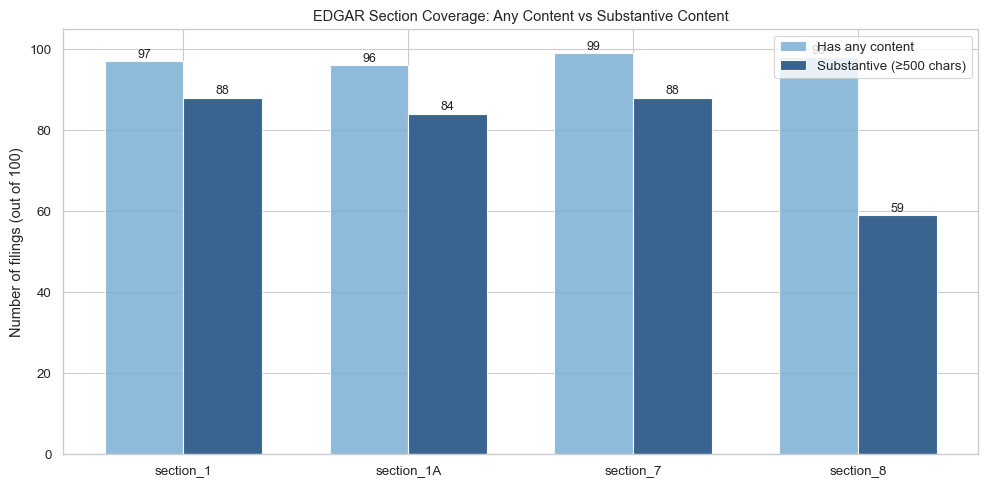

Saved: d:\General IT\AI-ML-LJMU\final_thesis\code\reports\figures\fig05_edgar_section_coverage.png


In [6]:
# Compare Phase 1 presence (any content) vs Phase 2 substantive count (>500 chars)
from src.data_loading.loaders import load_edgar_sample  # not actually re-loading; using already-loaded edgar_raw

SAMPLES_DIR = PROJECT_ROOT / "data" / "samples"
edgar_raw = pd.read_parquet(SAMPLES_DIR / "edgar_sample_100.parquet")

target_sections = ["section_1", "section_1A", "section_7", "section_8"]
presence_any = {s: (edgar_raw[s].str.len() > 0).sum() for s in target_sections}
presence_substantive = {s: (edgar_raw[s].str.len() >= 500).sum() for s in target_sections}

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(target_sections))
width = 0.35
ax.bar([i - width/2 for i in x], [presence_any[s] for s in target_sections],
       width, label="Has any content", color="#7BAFD4", alpha=0.85)
ax.bar([i + width/2 for i in x], [presence_substantive[s] for s in target_sections],
       width, label="Substantive (≥500 chars)", color="#2E5C8A", alpha=0.95)
ax.set_xticks(x)
ax.set_xticklabels(target_sections)
ax.set_ylabel("Number of filings (out of 100)")
ax.set_title("EDGAR Section Coverage: Any Content vs Substantive Content")
ax.legend()
ax.set_ylim(0, 105)

for i, s in enumerate(target_sections):
    ax.text(i - width/2, presence_any[s] + 1, str(presence_any[s]), ha="center", fontsize=9)
    ax.text(i + width/2, presence_substantive[s] + 1, str(presence_substantive[s]), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig05_edgar_section_coverage.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig05_edgar_section_coverage.png'}")

<h4>Figure 5 - EDGAR Section Coverage: Any Content vs Substantive Content.</h4>
<hr>

- Light bars show filings with any text in a section; dark bars show filings meeting the 500-character substantive threshold. 
- The gap is negligible for sections 1, 1A, and 7 (only 1–12 filings contain stub content), but significant for section 8, where 97 filings have some content but only 59 meet the substantive threshold. 
- The 38-filing gap corresponds to filers who embed their financial statements in section 15 exhibits rather than inline, leaving section 8 as a cross-reference pointer. 
- This coverage gap is a documented limitation of the EDGAR-CORPUS dataset; all three retrieval configurations in the ablation study face identical coverage, preserving comparative validity.


##### ===================================

- Methodology chapter: Figures 1, 4, 5 - shows the data and the cleaning decisions visually
- Discussion of limitations: Figure 5 specifically - supports the acknowledgment of section_8 coverage limitations
- Sample characterization section: Figure 2 - shows the formal/conversational structural contrast
- Sample representativeness: Figure 3 - shows sector coverage

For GICS stratification on EDGAR, you don't have sector data inline in EDGAR-CORPUS. Realistically, you have two options:

- Skip GICS for EDGAR, do random sampling, and acknowledge in your thesis that EDGAR sampling is random while earnings is sector-distributed
- Match EDGAR to earnings by CIK — but this is a significant engineering effort

For EDGAR across multiple years: pick 1-2 years (2019, 2020) for time efficiency. Don't go beyond. More years = more compute = more chunks = more time.
Sample size logic. Why 500 not 1000?

- 500 filings × ~3.5 sections × ~30 chunks = ~52K chunks for EDGAR
- 500 calls × 1.5 units × ~25 chunks = ~19K chunks for earnings
- Total ~71K chunks

At 71K chunks, dense embedding on Colab GPU takes ~45-60 min. Retrieval queries become slower. Tradeoff: more data = more confidence, but more time. 500 is the sweet spot for the timeline. If the embedding step finishes faster than expected, scale up to 1000 after the full pipeline is validated, not before.